In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/retail_sales.csv")

In [3]:
df.head

<bound method NDFrame.head of     Order_ID                  Order_Date Customer_ID     Product     Category  \
0    ORD0001  2025-01-01 00:00:00.000000     CUST168      Laptop  Electronics   
1    ORD0002  2025-01-01 08:44:41.081081     CUST099      Laptop  Electronics   
2    ORD0003  2025-01-01 17:29:22.162162     CUST156      Laptop  Electronics   
3    ORD0004  2025-01-02 02:14:03.243243     CUST131      Laptop  Electronics   
4    ORD0005  2025-01-02 10:58:44.324324     CUST096      Laptop  Electronics   
..       ...                         ...         ...         ...          ...   
995  ORD0996  2025-12-29 13:01:15.675675     CUST141      Laptop  Electronics   
996  ORD0997  2025-12-29 21:45:56.756756     CUST028  Headphones  Accessories   
997  ORD0998  2025-12-30 06:30:37.837837     CUST105  Headphones  Accessories   
998  ORD0999  2025-12-30 15:15:18.918918     CUST177    Keyboard  Accessories   
999  ORD1000  2025-12-31 00:00:00.000000     CUST037  Headphones  Accessories  

In [4]:
df.shape

(1000, 10)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category',
       'Quantity', 'Unit_Price', 'Region', 'Payment_Mode', 'Sales'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order_ID      1000 non-null   str  
 1   Order_Date    1000 non-null   str  
 2   Customer_ID   1000 non-null   str  
 3   Product       1000 non-null   str  
 4   Category      1000 non-null   str  
 5   Quantity      1000 non-null   int64
 6   Unit_Price    1000 non-null   int64
 7   Region        1000 non-null   str  
 8   Payment_Mode  1000 non-null   str  
 9   Sales         1000 non-null   int64
dtypes: int64(3), str(7)
memory usage: 145.9 KB


In [7]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Customer_ID     0
Product         0
Category        0
Quantity        0
Unit_Price      0
Region          0
Payment_Mode    0
Sales           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Quantity,Unit_Price,Sales
count,1000.000000,1000.000000,1000.000000
mean,3.020000,20305.400000,61166.200000
std,1.385467,21463.199197,76074.622219
min,1.000000,800.000000,800.000000
25%,2.000000,1500.000000,4000.000000
50%,3.000000,20000.000000,20000.000000
75%,4.000000,30000.000000,100000.000000
max,5.000000,60000.000000,300000.000000


In [10]:
df["Product"].value_counts()

Product
Tablet        181
Laptop        179
Mobile        171
Mouse         168
Headphones    153
Keyboard      148
Name: count, dtype: int64

In [11]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

Product
Laptop        32220000
Mobile        15510000
Tablet        11020000
Headphones     1335000
Keyboard        654000
Mouse           427200
Name: Sales, dtype: int64

<Axes: title={'center': 'Total Sales by Product'}, xlabel='Product', ylabel='Total Sales'>

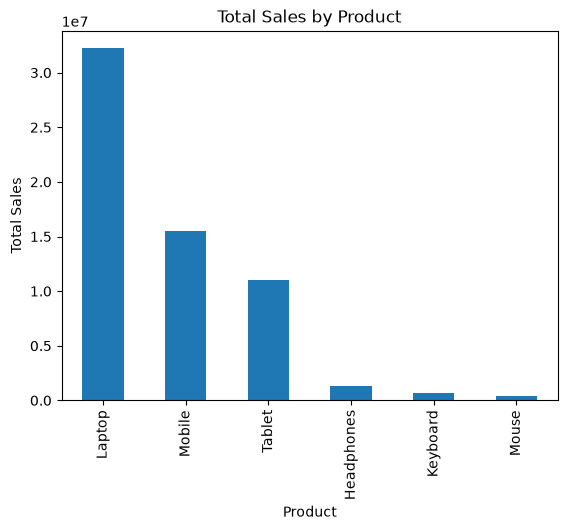

In [12]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False).plot(
    kind="bar",
    title="Total Sales by Product",
    xlabel="Product",
    ylabel="Total Sales"
)

In [13]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
South    19578800
West     14858800
East     14255500
North    12473100
Name: Sales, dtype: int64

<Axes: title={'center': 'Total Sales by Region'}, xlabel='Region', ylabel='Total Sales'>

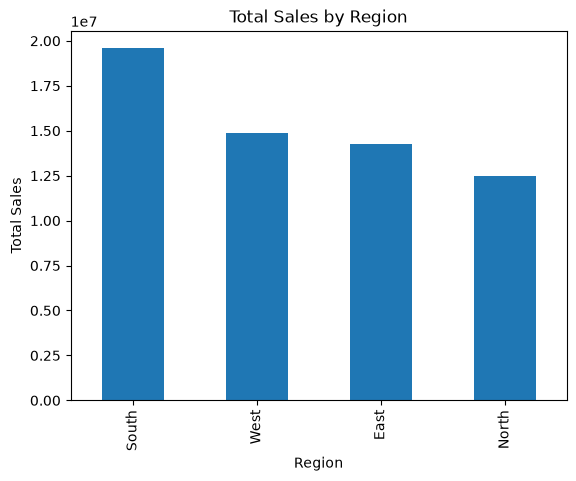

In [14]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False).plot(
    kind="bar",
    title="Total Sales by Region",
    xlabel="Region",
    ylabel="Total Sales"
)

In [15]:
df["Payment_Mode"].value_counts()

Payment_Mode
Credit Card    265
UPI            249
Cash           246
Debit Card     240
Name: count, dtype: int64

In [16]:
df.groupby("Payment_Mode")["Sales"].sum().sort_values(ascending=False)

Payment_Mode
Cash           16453100
UPI            16355700
Credit Card    14557600
Debit Card     13799800
Name: Sales, dtype: int64

In [17]:
df.groupby("Payment_Mode")["Sales"].mean().sort_values(ascending=False)

Payment_Mode
Cash           66882.520325
UPI            65685.542169
Debit Card     57499.166667
Credit Card    54934.339623
Name: Sales, dtype: float64

In [18]:
df["Order_Date"].dtype

<StringDtype(na_value=nan)>

In [19]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [20]:
df["Order_Date"].dtype

dtype('<M8[us]')

In [21]:
df["Month"] = df["Order_Date"].dt.month

In [22]:
df[["Order_Date", "Month"]].head()

,Order_Date,Month
0,2025-01-01 00:00:00.000000,1
1,2025-01-01 08:44:41.081081,1
2,2025-01-01 17:29:22.162162,1
3,2025-01-02 02:14:03.243243,1
4,2025-01-02 10:58:44.324324,1


In [23]:
df.groupby("Month")["Sales"].sum()

Month
1     6883000
2     4793000
3     5502400
4     4741000
5     4439000
6     5372500
7     4724100
8     4921000
9     5454100
10    4927700
11    4418800
12    4989600
Name: Sales, dtype: int64

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month', ylabel='Total Sales'>

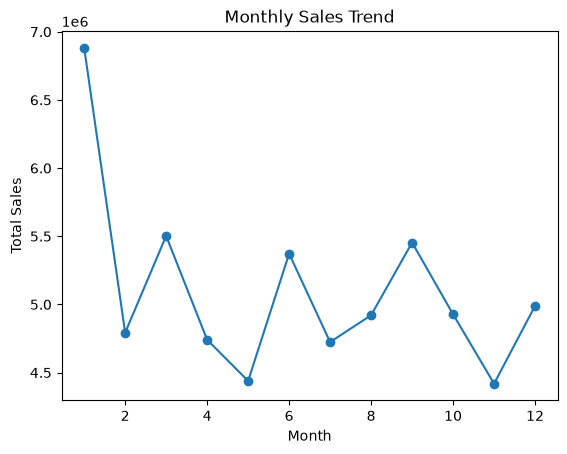

In [24]:
df.groupby("Month")["Sales"].sum().plot(
    kind="line",
    marker="o",
    title="Monthly Sales Trend",
    xlabel="Month",
    ylabel="Total Sales"
)

In [25]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Electronics    58750000
Accessories     2416200
Name: Sales, dtype: int64

In [26]:
df.groupby("Category")["Quantity"].sum()

Category
Accessories    1415
Electronics    1605
Name: Quantity, dtype: int64

<Axes: title={'center': 'Total Sales by Category'}, xlabel='Category', ylabel='Total Sales'>

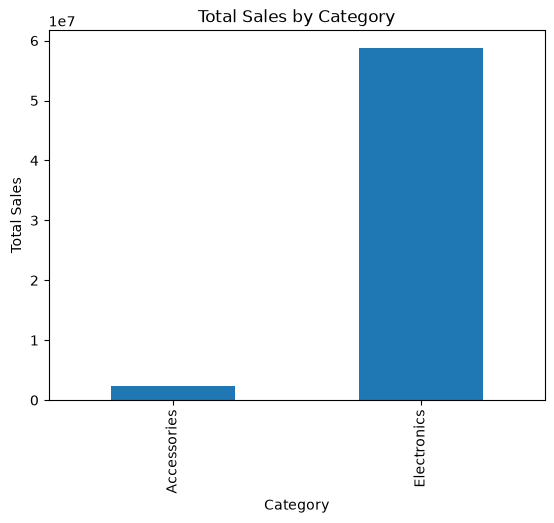

In [27]:
df.groupby("Category")["Sales"].sum().plot(
    kind="bar",
    title="Total Sales by Category",
    xlabel="Category",
    ylabel="Total Sales"
)

In [28]:
df.groupby("Product")["Sales"].mean().sort_values(ascending=False)

Product
Laptop        180000.000000
Mobile         90701.754386
Tablet         60883.977901
Headphones      8725.490196
Keyboard        4418.918919
Mouse           2542.857143
Name: Sales, dtype: float64

In [29]:
df.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False).head(10)

Customer_ID
CUST141    1170000
CUST066     912000
CUST028     885200
CUST162     829500
CUST178     829000
CUST101     766100
CUST121     759800
CUST193     741600
CUST199     730000
CUST156     708000
Name: Sales, dtype: int64

In [30]:
df["Customer_ID"].value_counts().head(10)

Customer_ID
CUST047    13
CUST177    11
CUST158    10
CUST066    10
CUST141     9
CUST003     9
CUST102     9
CUST044     9
CUST069     9
CUST028     9
Name: count, dtype: int64

In [31]:
df.groupby("Customer_ID")["Sales"].mean().sort_values(ascending=False).head(10)

Customer_ID
CUST022    200266.666667
CUST161    195000.000000
CUST051    180000.000000
CUST096    180000.000000
CUST049    160000.000000
CUST009    153750.000000
CUST115    150800.000000
CUST007    143000.000000
CUST156    141600.000000
CUST128    140000.000000
Name: Sales, dtype: float64

In [32]:
df.groupby(["Region", "Product"])["Sales"].sum().sort_values(ascending=False).head(10)

Region  Product
South   Laptop     11700000
West    Laptop      7200000
East    Laptop      7020000
North   Laptop      6300000
West    Mobile      4530000
East    Mobile      4200000
South   Mobile      4140000
        Tablet      3040000
North   Tablet      2880000
        Mobile      2640000
Name: Sales, dtype: int64

In [33]:
df.groupby(["Region", "Product"])["Sales"].sum().unstack()

Product,Headphones,Keyboard,Laptop,Mobile,Mouse,Tablet
Region,,,,,,
East,285000,154500,7020000,4200000,96000,2500000
North,345000,166500,6300000,2640000,141600,2880000
South,453000,153000,11700000,4140000,92800,3040000
West,252000,180000,7200000,4530000,96800,2600000


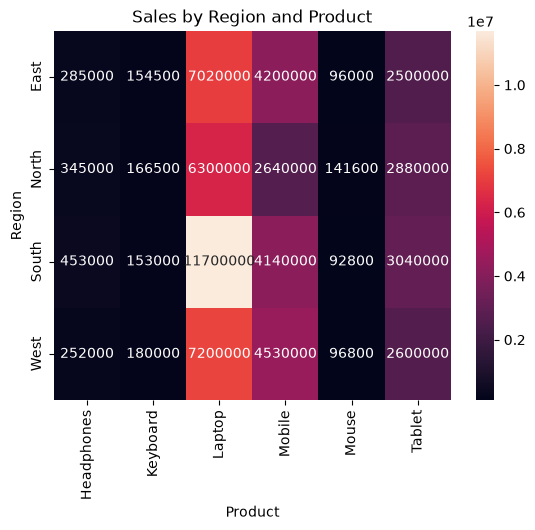

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

region_product_sales = df.groupby(
    ["Region", "Product"]
)["Sales"].sum().unstack()

sns.heatmap(
    region_product_sales,
    annot=True,
    fmt=".0f"
)

plt.title("Sales by Region and Product")
plt.xlabel("Product")
plt.ylabel("Region")
plt.show()

In [35]:
print("Total Sales:", df["Sales"].sum())
print("Total Orders:", df["Order_ID"].nunique())
print("Total Quantity Sold:", df["Quantity"].sum())

Total Sales: 61166200
Total Orders: 1000
Total Quantity Sold: 3020


In [36]:
average_order_value = df["Sales"].sum() / df["Order_ID"].nunique()

print("Average Order Value:", average_order_value)

Average Order Value: 61166.2


In [37]:
customer_orders = df["Customer_ID"].value_counts()

print(customer_orders.head(10))

Customer_ID
CUST047    13
CUST177    11
CUST158    10
CUST066    10
CUST141     9
CUST003     9
CUST102     9
CUST044     9
CUST069     9
CUST028     9
Name: count, dtype: int64


In [38]:
customer_sales = df.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False)

print(customer_sales.head(10))

Customer_ID
CUST141    1170000
CUST066     912000
CUST028     885200
CUST162     829500
CUST178     829000
CUST101     766100
CUST121     759800
CUST193     741600
CUST199     730000
CUST156     708000
Name: Sales, dtype: int64


In [39]:
customer_avg_sales = df.groupby("Customer_ID")["Sales"].mean().sort_values(ascending=False)

print(customer_avg_sales.head(10))

Customer_ID
CUST022    200266.666667
CUST161    195000.000000
CUST051    180000.000000
CUST096    180000.000000
CUST049    160000.000000
CUST009    153750.000000
CUST115    150800.000000
CUST007    143000.000000
CUST156    141600.000000
CUST128    140000.000000
Name: Sales, dtype: float64


In [40]:
customer_summary = df.groupby("Customer_ID").agg(
    Total_Sales=("Sales", "sum"),
    Total_Orders=("Order_ID", "nunique"),
    Average_Order_Value=("Sales", "mean")
)

customer_summary.head()

,Total_Sales,Total_Orders,Average_Order_Value
Customer_ID,,,
CUST001,59200,7,8457.142857
CUST002,277700,6,46283.333333
CUST003,440200,9,48911.111111
CUST004,121500,2,60750.000000
CUST005,290500,5,58100.000000


In [41]:
customer_summary.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Total_Sales,Total_Orders,Average_Order_Value
Customer_ID,,,
CUST141,1170000,9,130000.000000
CUST066,912000,10,91200.000000
CUST028,885200,9,98355.555556
CUST162,829500,8,103687.500000
CUST178,829000,6,138166.666667
CUST101,766100,8,95762.500000
CUST121,759800,8,94975.000000
CUST193,741600,8,92700.000000
CUST199,730000,8,91250.000000


In [42]:
customer_summary.sort_values(
    "Total_Orders",
    ascending=False
).head(10)

,Total_Sales,Total_Orders,Average_Order_Value
Customer_ID,,,
CUST047,434100,13,33392.307692
CUST177,543300,11,49390.909091
CUST066,912000,10,91200.000000
CUST158,345500,10,34550.000000
CUST028,885200,9,98355.555556
CUST069,316200,9,35133.333333
CUST003,440200,9,48911.111111
CUST114,305400,9,33933.333333
CUST102,336200,9,37355.555556


In [43]:
customer_summary["Total_Sales"].describe()

count    1.990000e+02
mean     3.073678e+05
std      2.075359e+05
min      1.500000e+03
25%      1.650000e+05
50%      2.700000e+05
75%      4.315500e+05
max      1.170000e+06
Name: Total_Sales, dtype: float64

In [44]:
average_customer_sales = customer_summary["Total_Sales"].mean()

high_value_customers = customer_summary[
    customer_summary["Total_Sales"] > average_customer_sales
]

print("Average Customer Sales:", average_customer_sales)
print("Number of High-Value Customers:", len(high_value_customers))

Average Customer Sales: 307367.8391959799
Number of High-Value Customers: 87


<Axes: title={'center': 'Distribution of Customer Sales'}, xlabel='Total Sales', ylabel='Frequency'>

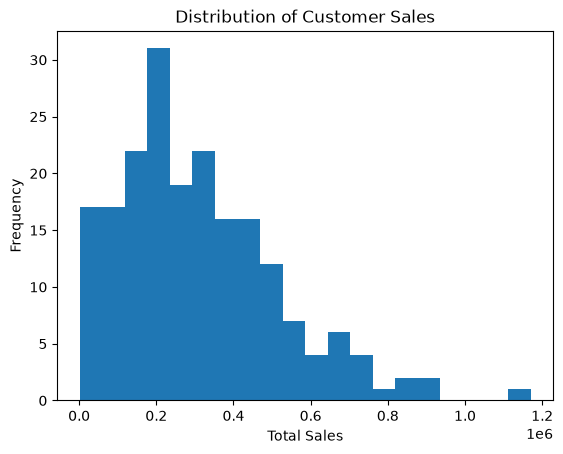

In [45]:
customer_summary["Total_Sales"].plot(
    kind="hist",
    bins=20,
    title="Distribution of Customer Sales",
    xlabel="Total Sales"
)

In [46]:
customer_summary["Total_Sales"].median()


np.float64(270000.0)

In [47]:
Q1 = customer_summary["Total_Sales"].quantile(0.25)
Q3 = customer_summary["Total_Sales"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 165000.0
Q3: 431550.0
IQR: 266550.0


In [48]:
upper_limit = Q3 + (1.5 * IQR)

print("Upper Limit:", upper_limit)

Upper Limit: 831375.0


In [49]:
outliers = customer_summary[
    customer_summary["Total_Sales"] > upper_limit
]

outliers

,Total_Sales,Total_Orders,Average_Order_Value
Customer_ID,,,
CUST028,885200,9,98355.555556
CUST066,912000,10,91200.000000
CUST141,1170000,9,130000.000000


In [50]:
df[df["Customer_ID"].isin(["CUST028", "CUST066", "CUST141"])]


,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Region,Payment_Mode,Sales,Month
24,ORD0025,2025-01-09 17:52:25.945945,CUST141,Laptop,Electronics,5,60000,East,UPI,300000,1
99,ORD0100,2025-02-06 01:43:47.027027,CUST141,Laptop,Electronics,5,60000,West,UPI,300000,2
141,ORD0142,2025-02-21 09:00:32.432432,CUST141,Mobile,Electronics,1,30000,West,Debit Card,30000,2
165,ORD0166,2025-03-02 02:52:58.378378,CUST028,Mobile,Electronics,3,30000,South,Credit Card,90000,3
170,ORD0171,2025-03-03 22:36:23.783783,CUST066,Mobile,Electronics,2,30000,West,UPI,60000,3
206,ORD0207,2025-03-17 01:25:02.702702,CUST066,Tablet,Electronics,1,20000,East,UPI,20000,3
243,ORD0244,2025-03-30 12:58:22.702702,CUST028,Laptop,Electronics,4,60000,East,Credit Card,240000,3
253,ORD0254,2025-04-03 04:25:13.513513,CUST066,Laptop,Electronics,2,60000,East,UPI,120000,4
264,ORD0265,2025-04-07 04:36:45.405405,CUST028,Tablet,Electronics,1,20000,South,Cash,20000,4
290,ORD0291,2025-04-16 15:58:33.513513,CUST028,Mouse,Accessories,1,800,West,Credit Card,800,4


In [51]:
df[df["Customer_ID"].isin(["CUST028", "CUST066", "CUST141"])].groupby(
    ["Customer_ID", "Product"]
)["Sales"].sum()

Customer_ID  Product   
CUST028      Headphones     12000
             Laptop        540000
             Mobile        210000
             Mouse           3200
             Tablet        120000
CUST066      Headphones     12000
             Laptop        420000
             Mobile        360000
             Tablet        120000
CUST141      Laptop        960000
             Mobile         90000
             Tablet        120000
Name: Sales, dtype: int64

In [52]:
latest_date = df["Order_Date"].max()

print("Latest Order Date:", latest_date)

Latest Order Date: 2025-12-31 00:00:00


In [53]:
recency = df.groupby("Customer_ID")["Order_Date"].max()

recency = (latest_date - recency).dt.days

recency.head()

Customer_ID
CUST001    32
CUST002    34
CUST003    88
CUST004    55
CUST005    98
Name: Order_Date, dtype: int64

In [54]:
frequency = df.groupby("Customer_ID")["Order_ID"].nunique()

frequency.head()

Customer_ID
CUST001    7
CUST002    6
CUST003    9
CUST004    2
CUST005    5
Name: Order_ID, dtype: int64

In [55]:
monetary = df.groupby("Customer_ID")["Sales"].sum()

monetary.head()

Customer_ID
CUST001     59200
CUST002    277700
CUST003    440200
CUST004    121500
CUST005    290500
Name: Sales, dtype: int64

In [56]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST001,32,7,59200
CUST002,34,6,277700
CUST003,88,9,440200
CUST004,55,2,121500
CUST005,98,5,290500


In [57]:
rfm.describe()

,Recency,Frequency,Monetary
count,199.000000,199.000000,1.990000e+02
mean,65.180905,5.025126,3.073678e+05
std,63.131076,2.135409,2.075359e+05
min,0.000000,1.000000,1.500000e+03
25%,20.000000,3.000000,1.650000e+05
50%,48.000000,5.000000,2.700000e+05
75%,87.000000,6.000000,4.315500e+05
max,362.000000,13.000000,1.170000e+06


<Axes: title={'center': 'Customer Recency Distribution'}, xlabel='Days Since Last Purchase', ylabel='Frequency'>

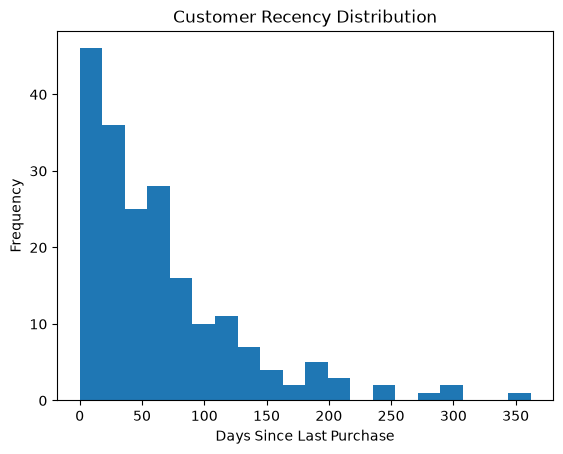

In [58]:
rfm["Recency"].plot(
    kind="hist",
    bins=20,
    title="Customer Recency Distribution",
    xlabel="Days Since Last Purchase"
)

<Axes: title={'center': 'Customer Frequency Distribution'}, xlabel='Number of Orders', ylabel='Frequency'>

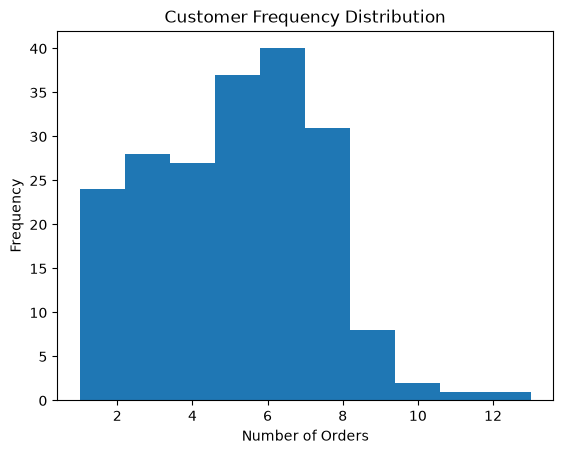

In [59]:
rfm["Frequency"].plot(
    kind="hist",
    bins=10,
    title="Customer Frequency Distribution",
    xlabel="Number of Orders"
)

<Axes: title={'center': 'Customer Monetary Distribution'}, xlabel='Total Spending', ylabel='Frequency'>

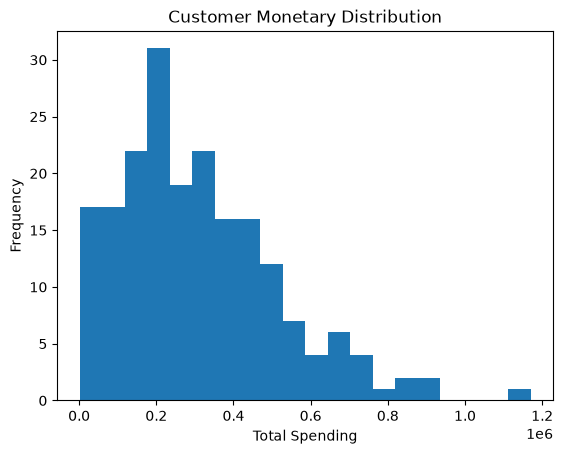

In [60]:
rfm["Monetary"].plot(
    kind="hist",
    bins=20,
    title="Customer Monetary Distribution",
    xlabel="Total Spending"
)

In [61]:
rfm["Recency_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm.head()

,Recency,Frequency,Monetary,Recency_Score
Customer_ID,,,,
CUST001,32,7,59200,4
CUST002,34,6,277700,4
CUST003,88,9,440200,2
CUST004,55,2,121500,3
CUST005,98,5,290500,2


In [62]:
rfm["Frequency_Score"] = pd.qcut(
    rfm["Frequency"],
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score
Customer_ID,,,,,
CUST001,32,7,59200,4,4
CUST002,34,6,277700,4,3
CUST003,88,9,440200,2,5
CUST004,55,2,121500,3,1
CUST005,98,5,290500,2,2


In [63]:
rfm["Frequency_Score"].value_counts().sort_index()

Frequency_Score
1    52
2    64
3    40
4    21
5    22
Name: count, dtype: int64

In [64]:
rfm["Monetary_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score
Customer_ID,,,,,,
CUST001,32,7,59200,4,4,1
CUST002,34,6,277700,4,3,3
CUST003,88,9,440200,2,5,4
CUST004,55,2,121500,3,1,1
CUST005,98,5,290500,2,2,3


In [65]:
rfm["RFM_Score"] = (
    rfm["Recency_Score"].astype(int)
    + rfm["Frequency_Score"].astype(int)
    + rfm["Monetary_Score"].astype(int)
)

rfm.head()

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,,,
CUST001,32,7,59200,4,4,1,9
CUST002,34,6,277700,4,3,3,10
CUST003,88,9,440200,2,5,4,11
CUST004,55,2,121500,3,1,1,5
CUST005,98,5,290500,2,2,3,7


In [66]:
rfm.sort_values(
    "RFM_Score",
    ascending=False
).head(10)

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,,,
CUST028,1,9,885200,5,5,5,15
CUST066,2,10,912000,5,5,5,15
CUST177,0,11,543300,5,5,5,15
CUST199,14,8,730000,5,5,5,15
CUST141,1,9,1170000,5,5,5,15
CUST047,5,13,434100,5,5,4,14
CUST006,16,9,472500,4,5,5,14
CUST162,22,8,829500,4,5,5,14
CUST193,20,8,741600,4,5,5,14


In [67]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
3     10
4      8
5     17
6     26
7     21
8     26
9     18
10    16
11    18
12    12
13    15
14     7
15     5
Name: count, dtype: int64

<Axes: title={'center': 'RFM Score Distribution'}, xlabel='RFM Score', ylabel='Frequency'>

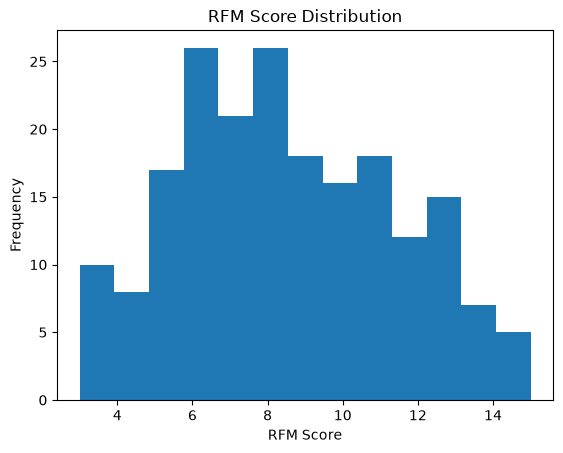

In [68]:
rfm["RFM_Score"].plot(
    kind="hist",
    bins=13,
    title="RFM Score Distribution",
    xlabel="RFM Score"
)

In [69]:
champions = rfm[
    (rfm["Recency_Score"] >= 4) &
    (rfm["Frequency_Score"] >= 4) &
    (rfm["Monetary_Score"] >= 4)
]

champions

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,,,
CUST003,88,9,440200,2,5,4,11
CUST006,16,9,472500,4,5,5,14
CUST014,33,7,560600,4,4,5,13
CUST016,45,8,445400,3,5,4,12
CUST044,55,9,686000,3,5,5,13
CUST086,67,7,500900,2,4,5,11
CUST101,68,8,766100,2,5,5,12
CUST116,35,8,441300,4,5,4,13
CUST121,53,8,759800,3,5,5,13


In [70]:
print("Number of Champions:", len(champions))

Number of Champions: 21


In [71]:
champions[[
    "Recency",
    "Frequency",
    "Monetary",
    "RFM_Score"
]].sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,RFM_Score
Customer_ID,,,,
CUST006,16,9,472500,14
CUST164,17,8,472000,14
CUST193,20,8,741600,14
CUST162,22,8,829500,14
CUST044,55,9,686000,13
CUST185,16,7,551200,13
CUST179,47,8,638800,13
CUST014,33,7,560600,13
CUST121,53,8,759800,13


In [72]:
loyal_customers = rfm[
    (rfm["Frequency_Score"] >= 4) &
    (rfm["Monetary_Score"] >= 4) &
    (rfm["RFM_Score"] < 15)
]

print("Number of Loyal Customers:", len(loyal_customers))

Number of Loyal Customers: 27


In [73]:
loyal_customers[
    ["Recency", "Frequency", "Monetary", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,RFM_Score
Customer_ID,,,,
CUST006,16,9,472500,14
CUST076,9,7,470000,14
CUST047,5,13,434100,14
CUST164,17,8,472000,14
CUST193,20,8,741600,14
CUST162,22,8,829500,14
CUST102,2,9,336200,14
CUST077,10,7,351200,13
CUST013,13,7,441400,13


In [74]:
loyal_customers = rfm[
    (rfm["Frequency_Score"] >= 4) &
    (rfm["Monetary_Score"] >= 4) &
    (rfm["Recency_Score"] < 4)
]

print("Number of Loyal Customers:", len(loyal_customers))

Number of Loyal Customers: 11


In [75]:
loyal_customers[
    ["Recency", "Frequency", "Monetary", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,RFM_Score
Customer_ID,,,,
CUST028,1,9,885200,15
CUST199,14,8,730000,15
CUST066,2,10,912000,15
CUST177,0,11,543300,15
CUST141,1,9,1170000,15
CUST076,9,7,470000,14
CUST047,5,13,434100,14
CUST102,2,9,336200,14
CUST013,13,7,441400,13


In [76]:
rfm.loc[
    ["CUST028", "CUST199", "CUST066"],
    ["Recency", "Recency_Score", "Frequency_Score", "Monetary_Score", "RFM_Score"]
]

,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,
CUST028,1,5,5,5,15
CUST199,14,5,5,5,15
CUST066,2,5,5,5,15


In [77]:
loyal_customers = rfm[
    (rfm["Frequency_Score"] >= 4) &
    (rfm["Monetary_Score"] >= 4) &
    (rfm["Recency_Score"] < 4)
]

print("Number of Loyal Customers:", len(loyal_customers))

Number of Loyal Customers: 11


In [78]:
loyal_customers[
    ["Recency", "Recency_Score", "Frequency_Score", "Monetary_Score", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,
CUST028,1,5,5,5,15
CUST199,14,5,5,5,15
CUST066,2,5,5,5,15
CUST177,0,5,5,5,15
CUST141,1,5,5,5,15
CUST076,9,5,4,5,14
CUST047,5,5,5,4,14
CUST102,2,5,5,4,14
CUST013,13,5,4,4,13


In [79]:
loyal_customers_new = rfm[
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4) &
    (rfm["Recency_Score"].astype(int) < 4)
]

print("Number of Loyal Customers:", len(loyal_customers_new))

loyal_customers_new[
    ["Recency", "Recency_Score", "Frequency_Score", "Monetary_Score", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

Number of Loyal Customers: 13


,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,
CUST044,55,3,5,5,13
CUST168,60,3,5,5,13
CUST179,47,3,5,5,13
CUST121,53,3,5,5,13
CUST101,68,2,5,5,12
CUST176,57,3,4,5,12
CUST140,56,3,4,5,12
CUST016,45,3,5,4,12
CUST003,88,2,5,4,11


In [80]:
potential_loyalists = rfm[
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["Frequency_Score"].astype(int).between(2, 3)) &
    (rfm["Monetary_Score"].astype(int).between(2, 3))
]

print("Number of Potential Loyalists:", len(potential_loyalists))

Number of Potential Loyalists: 20


In [81]:
potential_loyalists[
    ["Recency", "Frequency", "Monetary", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,RFM_Score
Customer_ID,,,,
CUST052,9,6,270000,11
CUST023,13,6,227000,11
CUST091,12,6,301700,11
CUST002,34,6,277700,10
CUST175,14,5,237700,10
CUST089,25,6,258000,10
CUST113,8,5,287500,10
CUST171,1,5,314000,10
CUST174,12,5,172200,9


In [82]:
at_risk = rfm[
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) >= 3) &
    (rfm["Monetary_Score"].astype(int) >= 3)
]

print("Number of At Risk Customers:", len(at_risk))

Number of At Risk Customers: 16


In [83]:
at_risk[
    ["Recency", "Frequency", "Monetary", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,RFM_Score
Customer_ID,,,,
CUST101,68,8,766100,12
CUST003,88,9,440200,11
CUST086,67,7,500900,11
CUST192,77,7,647500,11
CUST108,80,6,677600,10
CUST132,87,6,516000,10
CUST057,74,6,597200,10
CUST088,71,6,362800,9
CUST163,111,7,388000,9


In [84]:
need_attention = rfm[
    (rfm["Recency_Score"].astype(int) == 3) &
    (rfm["Frequency_Score"].astype(int).between(2, 3)) &
    (rfm["Monetary_Score"].astype(int).between(2, 3))
]

print("Number of Need Attention Customers:", len(need_attention))

Number of Need Attention Customers: 8


In [85]:
need_attention[
    ["Recency", "Frequency", "Monetary", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,RFM_Score
Customer_ID,,,,
CUST034,58,6,309000,9
CUST093,39,6,233700,9
CUST130,41,6,314500,9
CUST042,40,6,215400,8
CUST131,46,4,316600,8
CUST180,57,4,290000,8
CUST188,39,5,246000,8
CUST189,48,4,214000,7


In [86]:
lost_customers = rfm[
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) <= 2) &
    (rfm["Monetary_Score"].astype(int) <= 2)
]

print("Number of Lost Customers:", len(lost_customers))

Number of Lost Customers: 33


In [87]:
lost_customers[
    ["Recency", "Frequency", "Monetary", "RFM_Score"]
].sort_values("RFM_Score", ascending=False)

,Recency,Frequency,Monetary,RFM_Score
Customer_ID,,,,
CUST045,94,5,195300,6
CUST064,63,4,134000,6
CUST062,99,4,130900,6
CUST153,93,5,171000,6
CUST167,71,4,33000,5
CUST075,115,4,133900,5
CUST048,87,4,30000,5
CUST081,100,2,150000,5
CUST041,142,5,213600,5


In [88]:
assigned_customers = set(
    champions.index
).union(
    set(loyal_customers_new.index)
).union(
    set(potential_loyalists.index)
).union(
    set(at_risk.index)
).union(
    set(need_attention.index)
).union(
    set(lost_customers.index)
)

print("Unique assigned customers:", len(assigned_customers))
print("Unassigned customers:", len(rfm) - len(assigned_customers))

Unique assigned customers: 93
Unassigned customers: 106


In [89]:
unassigned_customers = rfm.loc[
    ~rfm.index.isin(assigned_customers)
]

print("Unassigned customers:", len(unassigned_customers))

unassigned_customers[
    ["Recency", "Frequency", "Monetary",
     "Recency_Score", "Frequency_Score",
     "Monetary_Score", "RFM_Score"]
].sort_values("RFM_Score", ascending=False).head(20)

Unassigned customers: 106


,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,,,
CUST066,2,10,912000,5,5,5,15
CUST028,1,9,885200,5,5,5,15
CUST199,14,8,730000,5,5,5,15
CUST141,1,9,1170000,5,5,5,15
CUST177,0,11,543300,5,5,5,15
CUST047,5,13,434100,5,5,4,14
CUST076,9,7,470000,5,4,5,14
CUST102,2,9,336200,5,5,4,14
CUST013,13,7,441400,5,4,4,13


In [90]:
champions = rfm[
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4)
]

print("Number of Champions:", len(champions))

Number of Champions: 19


In [91]:
print("CUST066 is Champion:", "CUST066" in champions.index)
print("CUST028 is Champion:", "CUST028" in champions.index)
print("CUST141 is Champion:", "CUST141" in champions.index)
print("CUST177 is Champion:", "CUST177" in champions.index)

CUST066 is Champion: True
CUST028 is Champion: True
CUST141 is Champion: True
CUST177 is Champion: True


In [92]:
loyal_customers = rfm[
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4) &
    (rfm["Recency_Score"].astype(int) < 4)
]

print("Number of Loyal Customers:", len(loyal_customers))

Number of Loyal Customers: 13


In [93]:
potential_loyalists = rfm[
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["Frequency_Score"].astype(int).between(2, 3)) &
    (rfm["Monetary_Score"].astype(int).between(2, 3))
]

print("Number of Potential Loyalists:", len(potential_loyalists))

Number of Potential Loyalists: 20


In [94]:
at_risk = rfm[
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) >= 3) &
    (rfm["Monetary_Score"].astype(int) >= 3)
]

print("Number of At Risk Customers:", len(at_risk))

Number of At Risk Customers: 16


In [95]:
need_attention = rfm[
    (rfm["Recency_Score"].astype(int) == 3) &
    (rfm["Frequency_Score"].astype(int).between(2, 3)) &
    (rfm["Monetary_Score"].astype(int).between(2, 3))
]

print("Number of Need Attention Customers:", len(need_attention))

Number of Need Attention Customers: 8


In [96]:
lost_customers = rfm[
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) <= 2) &
    (rfm["Monetary_Score"].astype(int) <= 2)
]

print("Number of Lost Customers:", len(lost_customers))

Number of Lost Customers: 33


In [97]:
segment_counts = pd.Series({
    "Champions": len(champions),
    "Loyal Customers": len(loyal_customers),
    "Potential Loyalists": len(potential_loyalists),
    "At Risk": len(at_risk),
    "Need Attention": len(need_attention),
    "Lost Customers": len(lost_customers)
})

print(segment_counts)
print("\nTotal segment assignments:", segment_counts.sum())
print("Total unique customers:", len(rfm))

Champions              19
Loyal Customers        13
Potential Loyalists    20
At Risk                16
Need Attention          8
Lost Customers         33
dtype: int64

Total segment assignments: 109
Total unique customers: 199


In [98]:
segment_df = pd.DataFrame(index=rfm.index)

segment_df["Champions"] = rfm.index.isin(champions.index)
segment_df["Loyal Customers"] = rfm.index.isin(loyal_customers.index)
segment_df["Potential Loyalists"] = rfm.index.isin(potential_loyalists.index)
segment_df["At Risk"] = rfm.index.isin(at_risk.index)
segment_df["Need Attention"] = rfm.index.isin(need_attention.index)
segment_df["Lost Customers"] = rfm.index.isin(lost_customers.index)

segment_df["Number_of_Segments"] = segment_df.sum(axis=1)

overlapping_customers = segment_df[
    segment_df["Number_of_Segments"] > 1
]

print("Number of overlapping customers:", len(overlapping_customers))

overlapping_customers

Number of overlapping customers: 5


,Champions,Loyal Customers,Potential Loyalists,At Risk,Need Attention,Lost Customers,Number_of_Segments
Customer_ID,,,,,,,
CUST003,False,True,False,True,False,False,2
CUST086,False,True,False,True,False,False,2
CUST101,False,True,False,True,False,False,2
CUST163,False,True,False,True,False,False,2
CUST192,False,True,False,True,False,False,2


In [99]:
print(rfm["RFM_Score"].value_counts().sort_index())

RFM_Score
3     10
4      8
5     17
6     26
7     21
8     26
9     18
10    16
11    18
12    12
13    15
14     7
15     5
Name: count, dtype: int64


In [100]:
all_segment_customers = set(
    champions.index
).union(
    loyal_customers.index
).union(
    potential_loyalists.index
).union(
    at_risk.index
).union(
    need_attention.index
).union(
    lost_customers.index
)

unassigned_customers = rfm.loc[
    ~rfm.index.isin(all_segment_customers)
]

print("Assigned customers:", len(all_segment_customers))
print("Unassigned customers:", len(unassigned_customers))

unassigned_customers.head(20)

Assigned customers: 104
Unassigned customers: 95


,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score
Customer_ID,,,,,,,
CUST001,32,7,59200,4,4,1,9
CUST004,55,2,121500,3,1,1,5
CUST005,98,5,290500,2,2,3,7
CUST007,18,3,429000,4,1,4,9
CUST008,194,6,135300,1,3,2,6
CUST009,107,2,307500,1,1,3,5
CUST010,9,5,514000,5,2,5,12
CUST011,92,4,224400,2,2,3,7
CUST017,15,6,373200,5,3,4,12


In [101]:
rfm[[
    "Recency_Score",
    "Frequency_Score",
    "Monetary_Score"
]].value_counts().sort_index()

Recency_Score  Frequency_Score  Monetary_Score
5              1                1                 4
                                2                 1
                                3                 1
                                4                 1
                                5                 1
                                                 ..
1              5                1                 0
                                2                 0
                                3                 0
                                4                 0
                                5                 0
Name: count, Length: 125, dtype: int64

In [102]:
score_combinations = (
    rfm[
        ["Recency_Score", "Frequency_Score", "Monetary_Score"]
    ]
    .value_counts()
    .sort_index()
)

print(score_combinations.to_string())

Recency_Score  Frequency_Score  Monetary_Score
5              1                1                  4
                                2                  1
                                3                  1
                                4                  1
                                5                  1
               2                1                  2
                                2                  1
                                3                  3
                                4                  3
                                5                  1
               3                1                  0
                                2                  0
                                3                  3
                                4                  3
                                5                  2
               4                1                  0
                                2                  0
                                3                  2

In [103]:
final_segments = pd.Series(index=rfm.index, dtype="object")

# 1. Champions
final_segments[
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4)
] = "Champions"

# 2. Loyal Customers
final_segments[
    final_segments.isna() &
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4)
] = "Loyal Customers"

# 3. Potential Loyalists
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["Frequency_Score"].astype(int).between(2, 3)) &
    (rfm["Monetary_Score"].astype(int).between(2, 3))
] = "Potential Loyalists"

# 4. At Risk
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) >= 3) &
    (rfm["Monetary_Score"].astype(int) >= 3)
] = "At Risk"

# 5. Need Attention
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) == 3) &
    (rfm["Frequency_Score"].astype(int).between(2, 3)) &
    (rfm["Monetary_Score"].astype(int).between(2, 3))
] = "Need Attention"

# 6. Lost Customers
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) <= 2) &
    (rfm["Monetary_Score"].astype(int) <= 2)
] = "Lost Customers"

# 7. Remaining customers
final_segments[final_segments.isna()] = "Others"

print(final_segments.value_counts())

Others                 95
Lost Customers         33
Potential Loyalists    20
Champions              19
Loyal Customers        13
At Risk                11
Need Attention          8
Name: count, dtype: int64


In [104]:
others = rfm[final_segments == "Others"]

print("Number of Others:", len(others))

others[[
    "Recency",
    "Frequency",
    "Monetary",
    "Recency_Score",
    "Frequency_Score",
    "Monetary_Score",
    "RFM_Score"
]].describe()

Number of Others: 95


,Recency,Frequency,Monetary,RFM_Score
count,95.000000,95.000000,95.000000,95.000000
mean,54.442105,4.526316,294011.578947,8.284211
std,49.129814,1.687514,178783.077798,2.350478
min,0.000000,1.000000,3900.000000,5.000000
25%,18.000000,3.000000,143950.000000,6.000000
50%,42.000000,5.000000,290500.000000,8.000000
75%,73.000000,6.000000,404100.000000,10.000000
max,216.000000,9.000000,829000.000000,13.000000


In [105]:
others["RFM_Score"].value_counts().sort_index()

RFM_Score
5      6
6     22
7     19
8     10
9      7
10     8
11    11
12     8
13     4
Name: count, dtype: int64

In [106]:
print("Recency Scores:")
print(others["Recency_Score"].value_counts().sort_index())

print("\nFrequency Scores:")
print(others["Frequency_Score"].value_counts().sort_index())

print("\nMonetary Scores:")
print(others["Monetary_Score"].value_counts().sort_index())

Recency Scores:
Recency_Score
5    23
4    20
3    21
2    15
1    16
Name: count, dtype: int64

Frequency Scores:
Frequency_Score
1    32
2    33
3    19
4     9
5     2
Name: count, dtype: int64

Monetary Scores:
Monetary_Score
1    23
2    13
3    18
4    26
5    15
Name: count, dtype: int64


In [107]:
final_segments = pd.Series(index=rfm.index, dtype="object")

# 1. Champions
final_segments[
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4)
] = "Champions"

# 2. Loyal Customers
final_segments[
    final_segments.isna() &
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4)
] = "Loyal Customers"

# 3. Potential Loyalists
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["RFM_Score"].astype(int) >= 9)
] = "Potential Loyalists"

# 4. At Risk
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) >= 3) &
    (rfm["Monetary_Score"].astype(int) >= 3)
] = "At Risk"

# 5. Need Attention
final_segments[
    final_segments.isna() &
    (rfm["RFM_Score"].astype(int).between(7, 8))
] = "Need Attention"

# 6. Lost Customers
final_segments[
    final_segments.isna() &
    (rfm["RFM_Score"].astype(int) <= 6)
] = "Lost Customers"

# Check whether anything remains
final_segments[final_segments.isna()] = "Others"

print(final_segments.value_counts())
print("\nTotal customers:", len(final_segments))

Lost Customers         61
Potential Loyalists    41
Need Attention         41
Champions              19
Loyal Customers        13
Others                 13
At Risk                11
Name: count, dtype: int64

Total customers: 199


In [108]:
others_final = rfm[final_segments == "Others"]

print(others_final[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Recency_Score",
        "Frequency_Score",
        "Monetary_Score",
        "RFM_Score"
    ]
].sort_values("RFM_Score", ascending=False))

             Recency  Frequency  Monetary Recency_Score Frequency_Score  \
Customer_ID                                                               
CUST046           42          6    601600             3               3   
CUST123           42          6    468400             3               3   
CUST125           51          6    530600             3               3   
CUST095           57          6    351400             3               3   
CUST070           44          7    226200             3               4   
CUST117           55          5    539000             3               2   
CUST107           37          5    670000             3               2   
CUST093           39          6    233700             3               3   
CUST034           58          6    309000             3               3   
CUST130           41          6    314500             3               3   
CUST133           99          5    541500             2               2   
CUST155           37     

In [109]:
# 5. Need Attention
final_segments[
    final_segments.isna() &
    (rfm["RFM_Score"].astype(int) >= 7)
] = "Need Attention"

In [110]:
# 6. Lost Customers
final_segments[
    final_segments.isna() &
    (rfm["RFM_Score"].astype(int) <= 6)
] = "Lost Customers"

In [111]:
# Remaining customers
final_segments[final_segments.isna()] = "Others"

print(final_segments.value_counts())
print("\nTotal customers:", len(final_segments))

Lost Customers         61
Potential Loyalists    41
Need Attention         41
Champions              19
Loyal Customers        13
Others                 13
At Risk                11
Name: count, dtype: int64

Total customers: 199


In [112]:
# Start fresh
final_segments = pd.Series(index=rfm.index, dtype="object")

# 1. Champions
final_segments[
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4)
] = "Champions"

# 2. Loyal Customers
final_segments[
    final_segments.isna() &
    (rfm["Frequency_Score"].astype(int) >= 4) &
    (rfm["Monetary_Score"].astype(int) >= 4)
] = "Loyal Customers"

# 3. Potential Loyalists
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) >= 4) &
    (rfm["RFM_Score"].astype(int) >= 9)
] = "Potential Loyalists"

# 4. At Risk
final_segments[
    final_segments.isna() &
    (rfm["Recency_Score"].astype(int) <= 2) &
    (rfm["Frequency_Score"].astype(int) >= 3) &
    (rfm["Monetary_Score"].astype(int) >= 3)
] = "At Risk"

# 5. Need Attention
final_segments[
    final_segments.isna() &
    (rfm["RFM_Score"].astype(int) >= 7)
] = "Need Attention"

# 6. Lost Customers
final_segments[
    final_segments.isna() &
    (rfm["RFM_Score"].astype(int) <= 6)
] = "Lost Customers"

# Any remaining customers
final_segments[final_segments.isna()] = "Others"

print(final_segments.value_counts())
print("\nTotal customers:", len(final_segments))

Lost Customers         61
Need Attention         54
Potential Loyalists    41
Champions              19
Loyal Customers        13
At Risk                11
Name: count, dtype: int64

Total customers: 199


In [113]:
rfm["Customer_Segment"] = final_segments

rfm.head()

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score,Customer_Segment
Customer_ID,,,,,,,,
CUST001,32,7,59200,4,4,1,9,Potential Loyalists
CUST002,34,6,277700,4,3,3,10,Potential Loyalists
CUST003,88,9,440200,2,5,4,11,Loyal Customers
CUST004,55,2,121500,3,1,1,5,Lost Customers
CUST005,98,5,290500,2,2,3,7,Need Attention


In [114]:
segment_summary = rfm.groupby("Customer_Segment").agg(
    Customers=("Monetary", "count"),
    Total_Sales=("Monetary", "sum"),
    Average_Sales=("Monetary", "mean")
)

segment_summary = segment_summary.sort_values(
    "Total_Sales",
    ascending=False
)

segment_summary

,Customers,Total_Sales,Average_Sales
Customer_Segment,,,
Need Attention,54,15519100,287390.740741
Potential Loyalists,41,14458900,352656.097561
Champions,19,11107700,584615.789474
Lost Customers,61,8292800,135947.540984
Loyal Customers,13,7416700,570515.384615
At Risk,11,4371000,397363.636364


<Axes: title={'center': 'Number of Customers by Segment'}, xlabel='Customer Segment', ylabel='Number of Customers'>

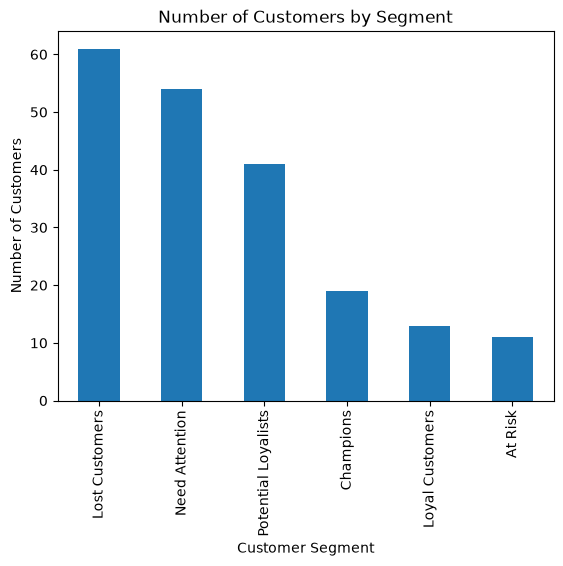

In [115]:
segment_counts = rfm["Customer_Segment"].value_counts()

segment_counts.plot(
    kind="bar",
    title="Number of Customers by Segment",
    xlabel="Customer Segment",
    ylabel="Number of Customers"
)

<Axes: title={'center': 'Total Sales by Customer Segment'}, xlabel='Customer Segment', ylabel='Total Sales'>

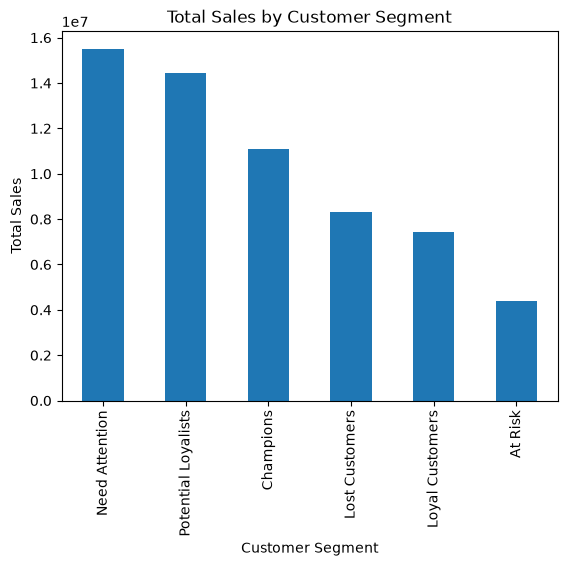

In [116]:
segment_summary["Total_Sales"].sort_values(ascending=False).plot(
    kind="bar",
    title="Total Sales by Customer Segment",
    xlabel="Customer Segment",
    ylabel="Total Sales"
)

<Axes: title={'center': 'Average Sales per Customer by Segment'}, xlabel='Customer Segment', ylabel='Average Sales'>

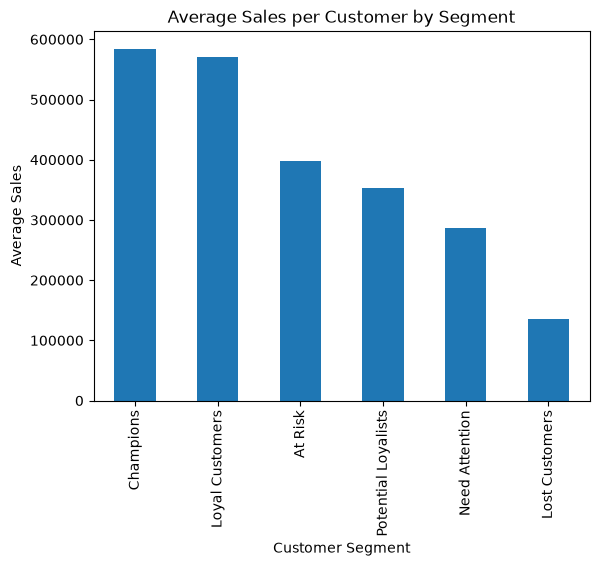

In [117]:
segment_summary["Average_Sales"].sort_values(ascending=False).plot(
    kind="bar",
    title="Average Sales per Customer by Segment",
    xlabel="Customer Segment",
    ylabel="Average Sales"
)

In [118]:
segment_summary

,Customers,Total_Sales,Average_Sales
Customer_Segment,,,
Need Attention,54,15519100,287390.740741
Potential Loyalists,41,14458900,352656.097561
Champions,19,11107700,584615.789474
Lost Customers,61,8292800,135947.540984
Loyal Customers,13,7416700,570515.384615
At Risk,11,4371000,397363.636364


In [119]:
rfm.to_csv("../data/customer_rfm_segments.csv", index=True)

print("RFM segmentation file saved successfully!")

RFM segmentation file saved successfully!


In [120]:
rfm_saved = pd.read_csv("../data/customer_rfm_segments.csv")

rfm_saved.head()

,Customer_ID,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score,Customer_Segment
0,CUST001,32,7,59200,4,4,1,9,Potential Loyalists
1,CUST002,34,6,277700,4,3,3,10,Potential Loyalists
2,CUST003,88,9,440200,2,5,4,11,Loyal Customers
3,CUST004,55,2,121500,3,1,1,5,Lost Customers
4,CUST005,98,5,290500,2,2,3,7,Need Attention
